# 🚢 Task 1: Data Cleaning & Visualization — Titanic Dataset

## Problem Statement
The Titanic disaster of 1912 is one of the most well-known maritime tragedies in history.
Out of 2,224 passengers and crew, more than 1,500 people lost their lives.

This project takes the raw Titanic passenger dataset and performs end-to-end data cleaning
followed by visual storytelling to answer the core question:
**What factors most influenced survival on the Titanic?**

---

## Dataset
- **Name:** Titanic Passenger Dataset
- **Source:** Built-in via Seaborn
- **Rows:** 891 passengers
- **Columns:** 15 features (age, sex, class, fare, survival etc.)

---

## What This Notebook Does
1. Loads and explores the raw dataset
2. Identifies missing values, duplicates, and outliers
3. Cleans and preprocesses the data
4. Creates visualizations to uncover survival patterns
5. Summarizes key findings with data storytelling

---

## Tools Used
- **Pandas** — data cleaning and manipulation
- **NumPy** — numerical operations
- **Matplotlib** — plotting charts
- **Seaborn** — statistical visualizations

---

## Expected Outcome
Learn data preprocessing, visualization, and storytelling with data.

Step 1: Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


Step 2: Load Dataset

In [2]:
# Load Titanic dataset directly from Seaborn (no download needed!)
df = sns.load_dataset('titanic')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


 Step 3: Initial Exploration

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df)

=== Missing Values ===
             Missing Count  Missing %
deck                   688  77.216611
age                    177  19.865320
embarked                 2   0.224467
embark_town              2   0.224467


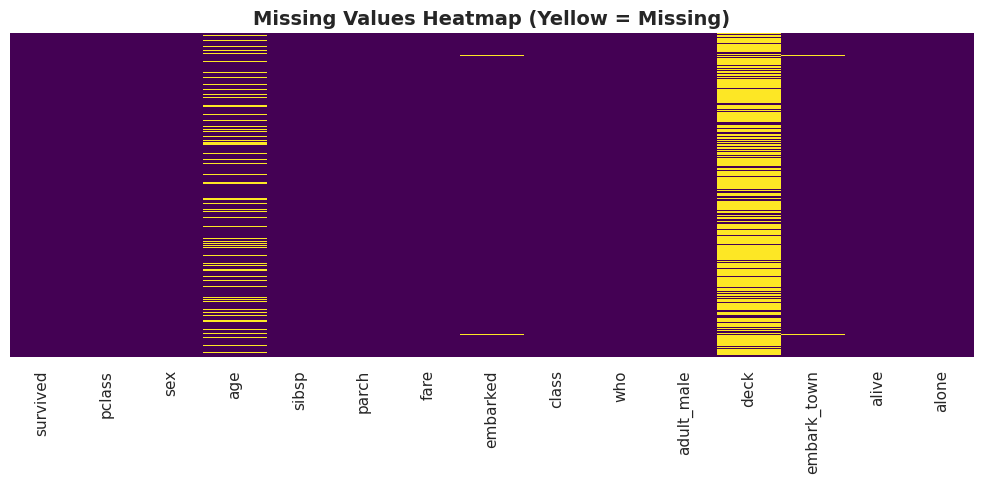

In [6]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Step 4: Data Cleaning

In [7]:
df_clean = df.copy()

# --- 1. Handle Missing Values ---

# Age: fill with median (robust to outliers)
age_before = df_clean['age'].copy()
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
print(f'Age: {age_before.isnull().sum()} missing values filled with median ({df["age"].median():.1f})')

# Embarked: fill with mode
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
print(f'Embarked: filled with mode ({df["embarked"].mode()[0]})')

# Deck/Cabin: too many missing (77%) — drop the column
df_clean.drop(columns=['deck'], inplace=True)
print('Deck column dropped (77% missing)')

# --- 2. Remove Duplicates ---
dups = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'\nDuplicates removed: {dups}')

# --- 3. Fix Data Types ---
df_clean['survived'] = df_clean['survived'].astype('category')
df_clean['pclass'] = df_clean['pclass'].astype('category')
print('\nData types fixed: survived, pclass → category')

print(f'\n✅ Cleaned shape: {df_clean.shape}')
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')

Age: 177 missing values filled with median (28.0)
Embarked: filled with mode (S)
Deck column dropped (77% missing)

Duplicates removed: 116

Data types fixed: survived, pclass → category

✅ Cleaned shape: (775, 14)
Remaining missing values: 2


Fare outliers detected: 102
Outliers capped at upper bound: 73.42


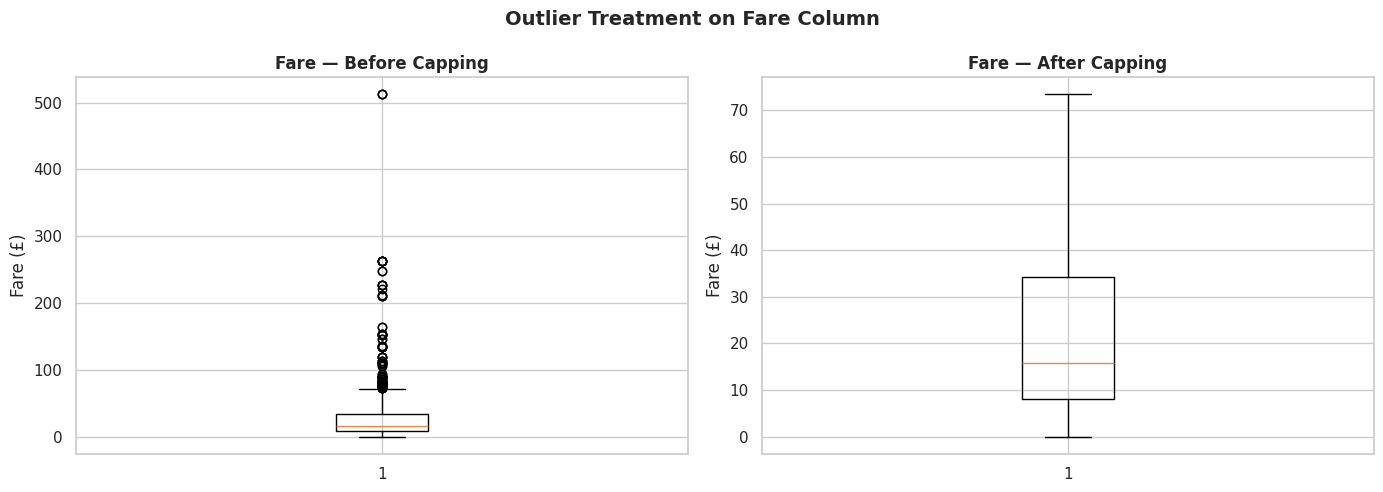

In [8]:
# --- 4. Outlier Detection & Treatment for Fare ---
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['fare'] < lower) | (df_clean['fare'] > upper)]
print(f'Fare outliers detected: {len(outliers)}')

# Cap outliers instead of dropping
df_clean['fare_capped'] = df_clean['fare'].clip(lower=lower, upper=upper)
print(f'Outliers capped at upper bound: {upper:.2f}')

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df_clean['fare'].dropna())
axes[0].set_title('Fare — Before Capping', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fare (£)')

axes[1].boxplot(df_clean['fare_capped'].dropna())
axes[1].set_title('Fare — After Capping', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fare (£)')

plt.suptitle('Outlier Treatment on Fare Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Step 5: Visualizations

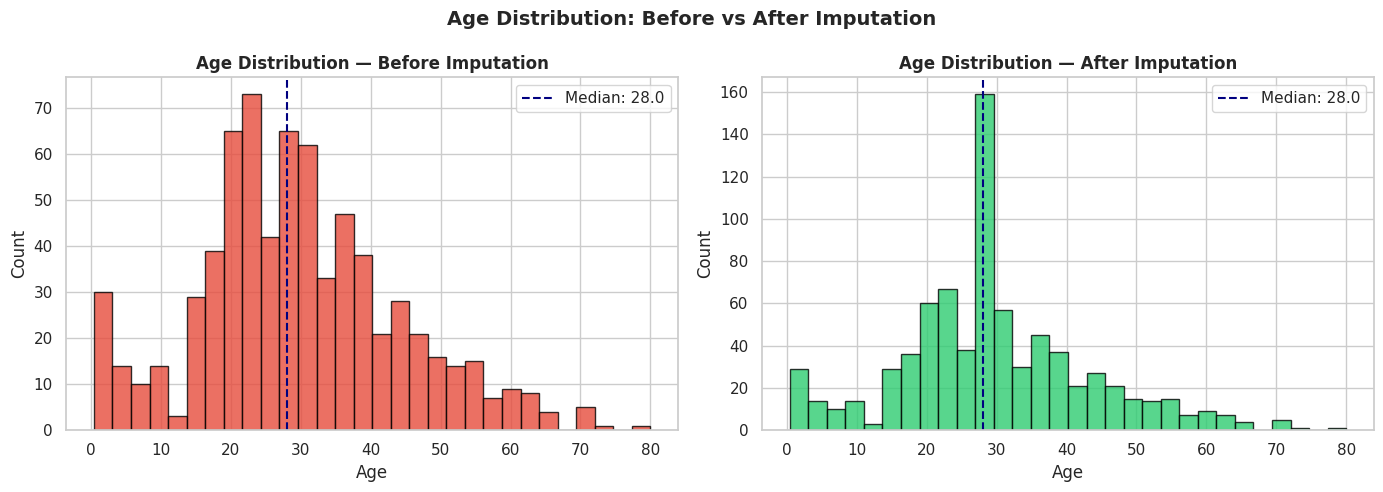

In [9]:
# --- Viz 1: Age Distribution Before vs After Imputation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'].dropna(), bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_title('Age Distribution — Before Imputation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['age'].median(), color='navy', linestyle='--', label=f'Median: {df["age"].median():.1f}')
axes[0].legend()

axes[1].hist(df_clean['age'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution — After Imputation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].axvline(df_clean['age'].median(), color='navy', linestyle='--', label=f'Median: {df_clean["age"].median():.1f}')
axes[1].legend()

plt.suptitle('Age Distribution: Before vs After Imputation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

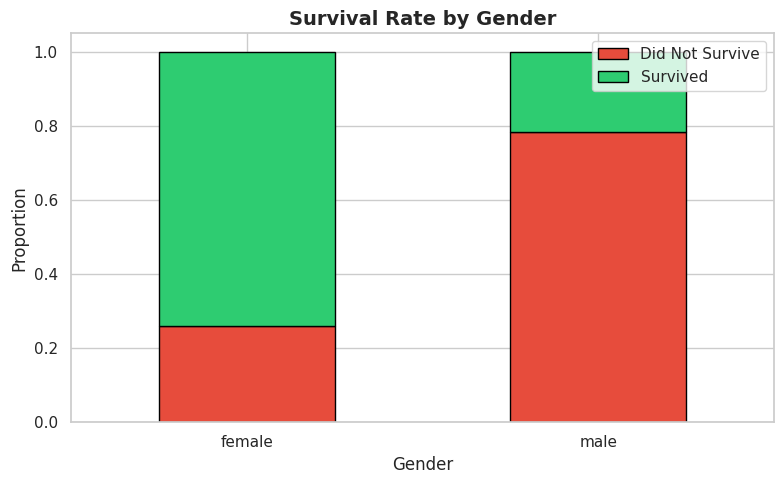

In [10]:
# --- Viz 2: Survival Rate by Gender ---
survival_gender = df_clean.groupby('sex')['survived'].value_counts(normalize=True).unstack()
survival_gender.columns = ['Did Not Survive', 'Survived']

survival_gender.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'],
                     figsize=(8, 5), edgecolor='black')
plt.title('Survival Rate by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

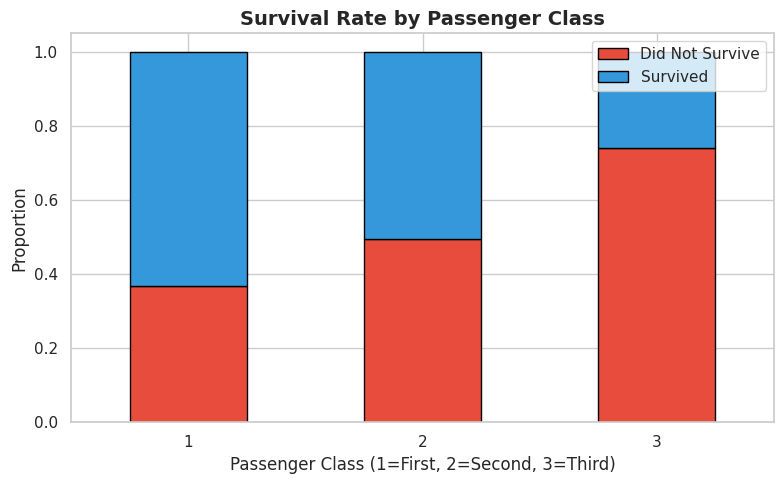

In [11]:
# --- Viz 3: Survival Rate by Passenger Class ---
survival_class = df_clean.groupby(df_clean['pclass'].astype(str))['survived'].value_counts(normalize=True).unstack()
survival_class.columns = ['Did Not Survive', 'Survived']

survival_class.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'],
                    figsize=(8, 5), edgecolor='black')
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

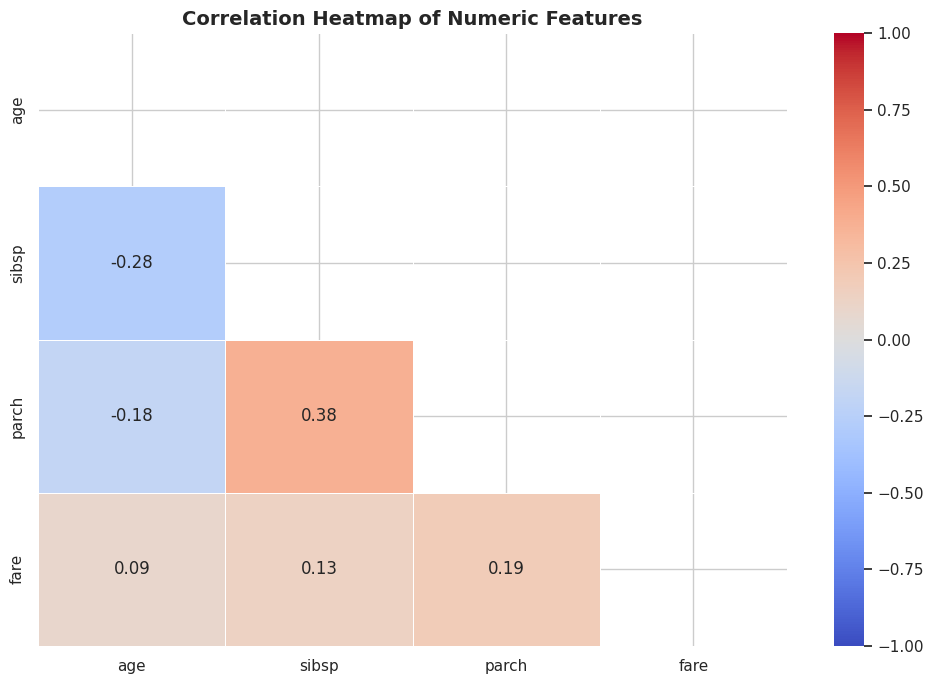

In [12]:
# --- Viz 4: Correlation Heatmap ---
numeric_cols = df_clean.select_dtypes(include=[np.number]).drop(columns=['fare_capped'])
corr = numeric_cols.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

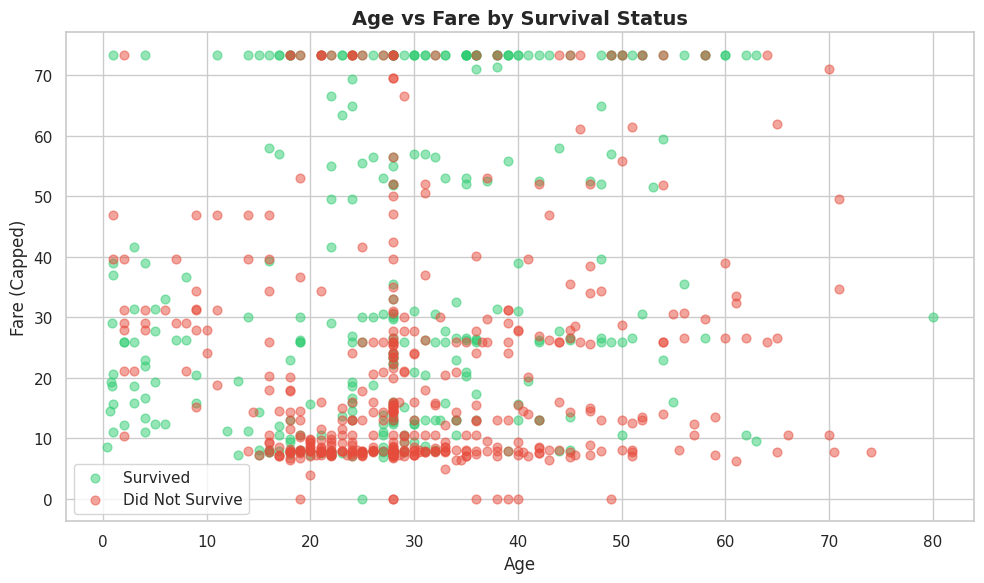

In [13]:
# --- Viz 5: Age vs Fare colored by Survival ---
survived_map = {0: 'Did Not Survive', 1: 'Survived'}
df_plot = df_clean.copy()
df_plot['survived_label'] = df_plot['survived'].astype(int).map(survived_map)

plt.figure(figsize=(10, 6))
for label, color in zip(['Survived', 'Did Not Survive'], ['#2ecc71', '#e74c3c']):
    subset = df_plot[df_plot['survived_label'] == label]
    plt.scatter(subset['age'], subset['fare_capped'], alpha=0.5, label=label, color=color, s=40)

plt.title('Age vs Fare by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Fare (Capped)')
plt.legend()
plt.tight_layout()
plt.show()

Step 6: Key Findings Summary

In [15]:
survival_rate = df_clean['survived'].astype(int).mean() * 100
female_survival = df_clean[df_clean['sex'] == 'female']['survived'].astype(int).mean() * 100
male_survival = df_clean[df_clean['sex'] == 'male']['survived'].astype(int).mean() * 100
class1_survival = df_clean[df_clean['pclass'] == 1]['survived'].astype(int).mean() * 100
class3_survival = df_clean[df_clean['pclass'] == 3]['survived'].astype(int).mean() * 100

print('='*50)
print('           KEY FINDINGS SUMMARY')
print('='*50)
print(f'\n Overall Survival Rate     : {survival_rate:.1f}%')
print(f' Female Survival Rate      : {female_survival:.1f}%')
print(f' Male Survival Rate        : {male_survival:.1f}%')
print(f' 1st Class Survival Rate   : {class1_survival:.1f}%')
print(f' 3rd Class Survival Rate   : {class3_survival:.1f}%')
print(f' Rows after cleaning       : {df_clean.shape[0]}')
print(f' Missing values remaining  : {df_clean.isnull().sum().sum()}')


           KEY FINDINGS SUMMARY

 Overall Survival Rate     : 41.3%
 Female Survival Rate      : 74.0%
 Male Survival Rate        : 21.5%
 1st Class Survival Rate   : 63.3%
 3rd Class Survival Rate   : 25.9%
 Rows after cleaning       : 775
 Missing values remaining  : 2
